# Tech Challenge - Machine Learning Tabular

Este notebook usa o dataset `breast_cancer_wisconsin.csv` para classificar tumores de mama como benignos ou malignos. O objetivo é construir uma base de IA explicável para apoio a triagem, sem substituir a decisão médica.

## 0. Ambiente virtual e dependências

Execute esta célula primeiro. Ela cria o venv do notebook, instala o `requirements.txt` correspondente e registra o kernel Jupyter. Se o notebook não estiver usando esse venv, a célula vai pedir para trocar o kernel antes de continuar.


In [1]:
from pathlib import Path
import hashlib
import os
import subprocess
import sys


def find_project_root_for_setup(start: Path | None = None) -> Path:
    """Locate the project root so setup works from any notebook folder."""
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'breast_cancer_wisconsin.csv').is_file() and (candidate / 'cnn_data').is_dir():
            return candidate
    raise FileNotFoundError('Project root not found. Keep breast_cancer_wisconsin.csv and cnn_data/ at the root.')


PROJECT_ROOT_SETUP = find_project_root_for_setup()
VENV_DIR = PROJECT_ROOT_SETUP / '.venv-tabular'
REQUIREMENTS_FILE = PROJECT_ROOT_SETUP / 'notebooks/tabular/requirements.txt'
KERNEL_NAME = 'tech-challenge-tabular'
KERNEL_DISPLAY_NAME = 'Tech Challenge Tabular'


def venv_python_path(venv_dir: Path) -> Path:
    """Return the Python executable path for Linux/macOS or Windows."""
    if os.name == 'nt':
        return venv_dir / 'Scripts' / 'python.exe'
    return venv_dir / 'bin' / 'python'


VENV_PYTHON = venv_python_path(VENV_DIR)
if not VENV_PYTHON.exists():
    print(f'Creating virtual environment: {VENV_DIR.relative_to(PROJECT_ROOT_SETUP)}')
    subprocess.check_call([sys.executable, '-m', 'venv', str(VENV_DIR)])
else:
    print(f'Virtual environment already exists: {VENV_DIR.relative_to(PROJECT_ROOT_SETUP)}')

requirements_hash = hashlib.sha256(REQUIREMENTS_FILE.read_bytes()).hexdigest()
marker_file = VENV_DIR / f'.requirements-{requirements_hash}.installed'

if marker_file.exists():
    print('Requirements already installed for the current requirements.txt hash.')
else:
    print(f'Installing requirements from: {REQUIREMENTS_FILE.relative_to(PROJECT_ROOT_SETUP)}')
    subprocess.check_call([str(VENV_PYTHON), '-m', 'pip', 'install', '--upgrade', 'pip'])
    subprocess.check_call([str(VENV_PYTHON), '-m', 'pip', 'install', '-r', str(REQUIREMENTS_FILE)])

    # Remove old markers so a changed requirements.txt triggers a fresh install later.
    for old_marker in VENV_DIR.glob('.requirements-*.installed'):
        old_marker.unlink(missing_ok=True)
    marker_file.write_text('ok\n', encoding='utf-8')

subprocess.check_call([
    str(VENV_PYTHON),
    '-m',
    'ipykernel',
    'install',
    '--user',
    '--name',
    KERNEL_NAME,
    '--display-name',
    KERNEL_DISPLAY_NAME,
])

running_in_target_venv = Path(sys.prefix).resolve() == VENV_DIR.resolve()
print(f'Target venv: {VENV_DIR}')
print(f'Current Python prefix: {sys.prefix}')

if not running_in_target_venv:
    raise SystemExit(
        f'Environment prepared. Now switch the notebook kernel to "{KERNEL_DISPLAY_NAME}" '
        'and run the notebook again from the beginning.'
    )

print('Notebook is running inside the expected virtual environment.')


Virtual environment already exists: .venv-tabular
Requirements already installed for the current requirements.txt hash.
Installed kernelspec tech-challenge-tabular in /Users/camila/Library/Jupyter/kernels/tech-challenge-tabular
Target venv: /Users/camila/Documents/Documentos - MacBook Pro de Camila/FIAP - IA para DEVS/tech_challenge_a/.venv-tabular
Current Python prefix: /Users/camila/Documents/Documentos - MacBook Pro de Camila/FIAP - IA para DEVS/tech_challenge_a/.venv-tabular
Notebook is running inside the expected virtual environment.


## 1. Configuração e caminhos portáteis

A função abaixo procura a raiz do projeto a partir da pasta atual. Isso evita caminhos absolutos e permite executar o notebook a partir da raiz, de `notebooks/` ou da pasta do próprio notebook.

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

RANDOM_STATE = 42


def find_project_root(start: Path | None = None) -> Path:
    """Find the project root without relying on an absolute local path."""
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        has_tabular_data = (candidate / 'breast_cancer_wisconsin.csv').is_file()
        has_cnn_data = (candidate / 'cnn_data').is_dir()
        if has_tabular_data and has_cnn_data:
            return candidate
    raise FileNotFoundError(
        'Project root not found. Keep breast_cancer_wisconsin.csv and cnn_data/ in the repository root.'
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'breast_cancer_wisconsin.csv'
REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset: {DATA_PATH.relative_to(PROJECT_ROOT)}')

Project root: /Users/camila/Documents/Documentos - MacBook Pro de Camila/FIAP - IA para DEVS/tech_challenge_a
Dataset: breast_cancer_wisconsin.csv


## 2. Carregamento e limpeza inicial

O CSV possui uma coluna `id`, que identifica o exame/paciente mas não deve ser usada como atributo preditivo. Também pode haver uma coluna vazia criada por vírgula final no arquivo original.

In [3]:
raw_df = pd.read_csv(DATA_PATH)

# Remove colunas totalmente vazias, como Unnamed: 32 em algumas versões do dataset.
df = raw_df.dropna(axis=1, how='all').copy()

# O identificador não representa uma característica clínica do tumor.
if 'id' in df.columns:
    df = df.drop(columns='id')

print(f'Linhas: {df.shape[0]} | Colunas úteis: {df.shape[1]}')
display(df.head())
display(df.dtypes.to_frame('tipo').head(10))

Linhas: 569 | Colunas uteis: 31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,tipo
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


Valores ausentes por coluna:


Series([], dtype: int64)

,quantidade
diagnosis,
Benigno,357
Maligno,212


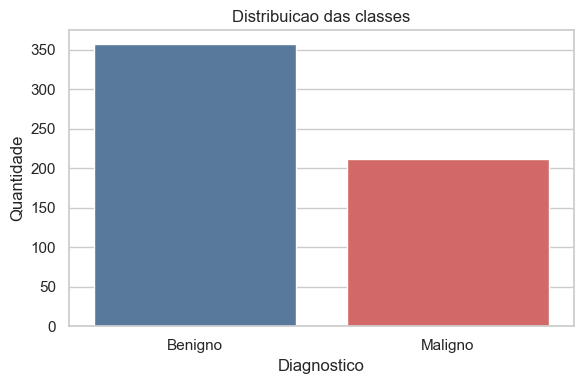

In [4]:
# Mapeia o alvo para binário: maligno é a classe positiva porque é o maior risco clínico.
target_map = {'B': 0, 'M': 1}
df['diagnosis'] = df['diagnosis'].map(target_map)

missing_by_column = df.isna().sum().sort_values(ascending=False)
print('Valores ausentes por coluna:')
display(missing_by_column[missing_by_column > 0])

class_distribution = df['diagnosis'].value_counts().rename(index={0: 'Benigno', 1: 'Maligno'})
display(class_distribution.to_frame('quantidade'))

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='diagnosis', palette=['#4c78a8', '#e45756'])
ax.set_xticklabels(['Benigno', 'Maligno'])
ax.set_title('Distribuição das classes')
ax.set_xlabel('Diagnóstico')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tabular_class_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Análise exploratoria

A análise compara estatísticas por classe e usa correlação para destacar variáveis com maior relação linear com o diagnóstico.

In [5]:
display(df.describe().T)

# Medias por classe ajudam a entender quais medidas mudam entre benigno e maligno.
group_means = df.groupby('diagnosis').mean(numeric_only=True).T
group_means.columns = ['Benigno', 'Maligno']
group_means['diferença_abs'] = (group_means['Maligno'] - group_means['Benigno']).abs()
display(group_means.sort_values('diferença_abs', ascending=False).head(12))

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


,Benigno,Maligno,diferenca_abs
area_worst,558.899440,1422.286321,863.386881
area_mean,462.790196,978.376415,515.586219
perimeter_worst,87.005938,141.370330,54.364392
area_se,21.135148,72.672406,51.537257
perimeter_mean,78.075406,115.365377,37.289971
radius_worst,13.379801,21.134811,7.755010
texture_worst,23.515070,29.318208,5.803138
radius_mean,12.146524,17.462830,5.316306
texture_mean,17.914762,21.604906,3.690144
perimeter_se,2.000321,4.323929,2.323608


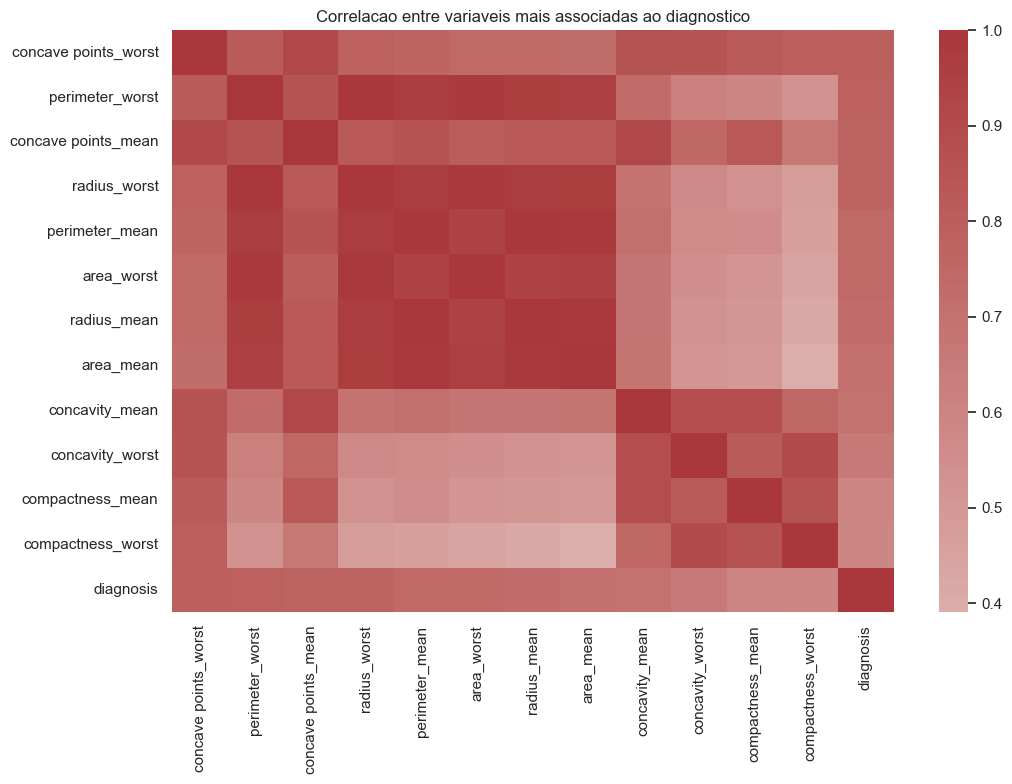

,correlacao_com_diagnostico
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


In [6]:
corr = df.corr(numeric_only=True)
top_corr_features = (
    corr['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)

# O heatmap fica mais legível com as variáveis mais correlacionadas ao alvo.
heatmap_columns = top_corr_features + ['diagnosis']
plt.figure(figsize=(11, 8))
sns.heatmap(corr.loc[heatmap_columns, heatmap_columns], cmap='vlag', center=0, annot=False)
plt.title('Correlação entre variáveis mais associadas ao diagnóstico')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tabular_correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

display(corr['diagnosis'].drop('diagnosis').sort_values(key=np.abs, ascending=False).head(12).to_frame('correlação_com_diagnóstico'))

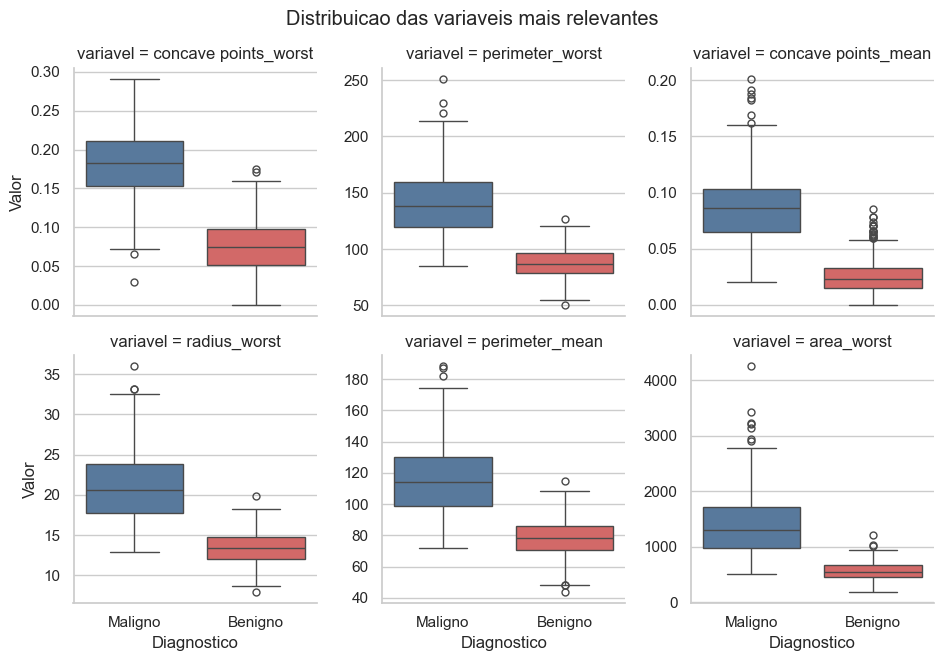

In [7]:
# Distribuições das principais variáveis mostram separação visual entre classes.
plot_features = top_corr_features[:6]
long_df = df.melt(id_vars='diagnosis', value_vars=plot_features, var_name='variável', value_name='valor')
long_df['diagnosis_label'] = long_df['diagnosis'].map({0: 'Benigno', 1: 'Maligno'})

g = sns.catplot(
    data=long_df,
    x='diagnosis_label',
    y='valor',
    col='variável',
    col_wrap=3,
    kind='box',
    sharey=False,
    height=3.2,
    palette=['#4c78a8', '#e45756'],
)
g.set_axis_labels('Diagnóstico', 'Valor')
g.fig.suptitle('Distribuição das variáveis mais relevantes', y=1.03)
plt.savefig(REPORTS_DIR / 'tabular_top_feature_distributions.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Separação treino/teste e modelagem

A divisão é estratificada para preservar a proporção de benignos e malignos. Modelos que dependem de escala recebem `StandardScaler` em um `Pipeline`.

In [8]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
display(y_train.value_counts(normalize=True).rename(index={0: 'Benigno', 1: 'Maligno'}).to_frame('proporção_treino'))
display(y_test.value_counts(normalize=True).rename(index={0: 'Benigno', 1: 'Maligno'}).to_frame('proporção_teste'))

models = {
    'Regressão Logística': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
        ]
    ),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

Treino: (455, 30) | Teste: (114, 30)


,proporcao_treino
diagnosis,
Benigno,0.626374
Maligno,0.373626


,proporcao_teste
diagnosis,
Benigno,0.631579
Maligno,0.368421


In [9]:
trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model

    # Recall da classe maligna mede quantos casos de maior risco foram encontrados.
    results.append(
        {
            'modelo': name,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_maligno': precision_score(y_test, y_pred, pos_label=1),
            'recall_maligno': recall_score(y_test, y_pred, pos_label=1),
            'f1_maligno': f1_score(y_test, y_pred, pos_label=1),
        }
    )

results_df = pd.DataFrame(results).sort_values(['recall_maligno', 'f1_maligno'], ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]['modelo']
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

print(f'Melhor modelo pelo critério recall + F1 para maligno: {best_model_name}')
print(classification_report(y_test, best_predictions, target_names=['Benigno', 'Maligno']))

,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno
0,Regressao Logistica,0.973684,0.97561,0.952381,0.963855
2,Random Forest,0.964912,1.00000,0.904762,0.950000
1,Arvore de Decisao,0.929825,0.92500,0.880952,0.902439


Melhor modelo pelo criterio recall + F1 para maligno: Regressao Logistica
              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



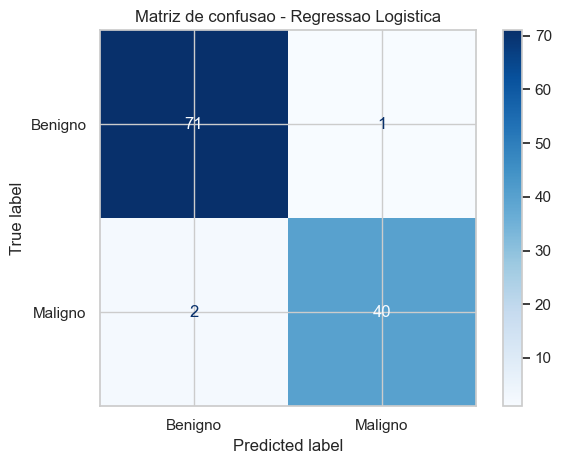

Interpretacao rapida: falsos negativos sao malignos previstos como benignos, o erro mais sensivel neste problema.


In [10]:
cm = confusion_matrix(y_test, best_predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de confusão - {best_model_name}')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tabular_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

print('Interpretação rápida: falsos negativos são malignos previstos como benignos, o erro mais sensível neste problema.')

## 5. Explicabilidade

A Random Forest oferece importância de variáveis. O SHAP complementa a leitura ao mostrar como cada variável contribui para as previsões.

,variavel,importancia
22,perimeter_worst,0.143452
23,area_worst,0.140852
27,concave points_worst,0.104640
7,concave points_mean,0.099638
20,radius_worst,0.074969
0,radius_mean,0.056577
2,perimeter_mean,0.051317
6,concavity_mean,0.048216
26,concavity_worst,0.039018
3,area_mean,0.038366


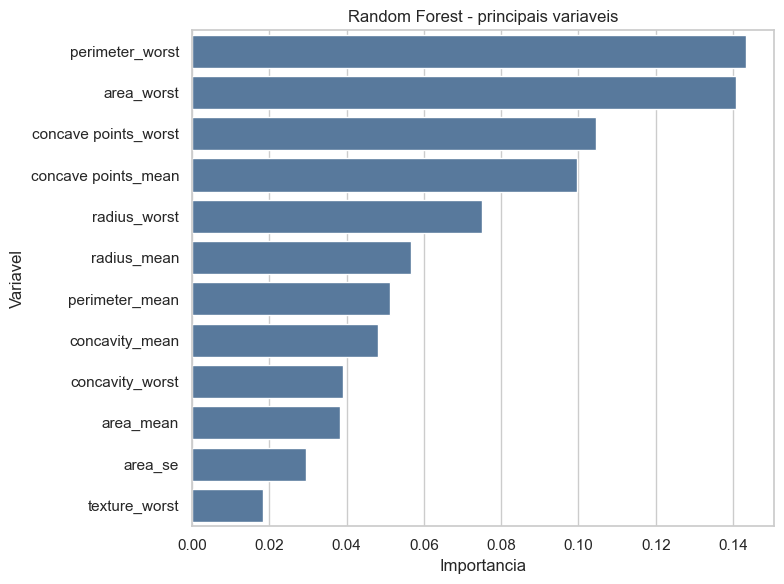

In [11]:
rf_model = trained_models['Random Forest']
feature_importance = (
    pd.DataFrame({'variável': X.columns, 'importância': rf_model.feature_importances_})
    .sort_values('importância', ascending=False)
    .head(12)
)

display(feature_importance)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance, x='importância', y='variável', color='#4c78a8')
plt.title('Random Forest - principais variáveis')
plt.xlabel('Importancia')
plt.ylabel('Variavel')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tabular_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

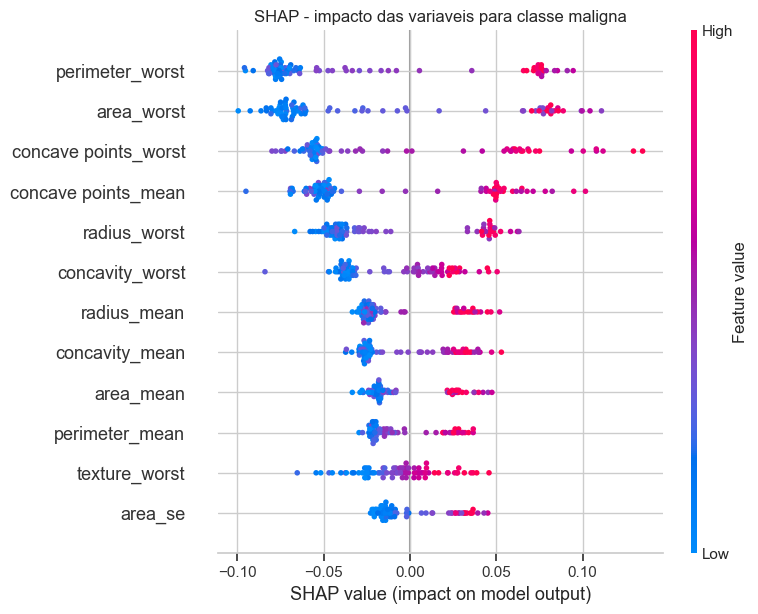

In [12]:
try:
    import shap

    # Amostra pequena mantém o SHAP rápido e suficiente para explicação didática.
    shap_sample = X_test.sample(n=min(80, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(shap_sample)

    if isinstance(shap_values, list):
        shap_values_positive = shap_values[1]
    elif getattr(shap_values, 'ndim', 0) == 3:
        shap_values_positive = shap_values[:, :, 1]
    else:
        shap_values_positive = shap_values

    shap.summary_plot(shap_values_positive, shap_sample, show=False, max_display=12)
    plt.title('SHAP - impacto das variáveis para classe maligna')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'tabular_shap_summary.png', dpi=160, bbox_inches='tight')
    plt.show()
except Exception as exc:
    print(f'SHAP não foi executado neste ambiente: {exc}')

## 6. Discussão crítica

- O modelo tabular pode apoiar triagem ao indicar exames com maior risco de malignidade.
- A métrica mais importante é o recall da classe maligna, pois falso negativo pode atrasar investigação médica.
- Mesmo com bom desempenho, o modelo não deve ser usado como diagnóstico automático. Ele deve apoiar a priorização e a decisão final sempre deve ser de profissionais de saúde.
- Validações futuras deveriam incluir dados externos, monitoramento de viéses e revisão clínica dos erros.